<a href="https://colab.research.google.com/github/positivefunctionIN/Plant_Leaf_Disease_Prediction_2.0/blob/main/Plant_Leaf_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np

print(tf.__version__)

2.20.0


In [11]:
!pip install -q kaggle

In [12]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_f8f365ac5c0ba445883f261d2f0f533d"

In [13]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:03<00:00, 182MB/s]



In [14]:
!unzip plantdisease.zip -d /content/plant_data

Streaming output truncated to the last 5000 lines.
  inflating: /content/plant_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: /content/plant_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: /content/plant_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: /content/plant_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: /content/plant_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: /content/plant_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV

In [15]:
import os
print(os.listdir("/content/plant_data"))

['plantvillage', 'PlantVillage']


In [16]:
import os

print("plantvillage:", os.listdir("/content/plant_data/plantvillage")[:5])
print("PlantVillage:", os.listdir("/content/plant_data/PlantVillage")[:5])

plantvillage: ['PlantVillage']
PlantVillage: ['Tomato_healthy', 'Tomato_Early_blight', 'Potato___Early_blight', 'Tomato__Tomato_mosaic_virus', 'Potato___healthy']


In [17]:
dataset_path = "/content/plant_data/PlantVillage"

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,519,887 (24.87 MB)

 Trainable params: 6,519,887 (24.87 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    train_generator,
    validation_data = validation_generator,
    epochs = 10
)

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.5383 - loss: 1.4496 - val_accuracy: 0.7460 - val_loss: 0.7652
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.7399 - loss: 0.7888 - val_accuracy: 0.8176 - val_loss: 0.5504
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.7953 - loss: 0.6106 - val_accuracy: 0.8692 - val_loss: 0.3997
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - accuracy: 0.8357 - loss: 0.4886 - val_accuracy: 0.8981 - val_loss: 0.3061
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.8613 - loss: 0.4099 - val_accuracy: 0.8996 - val_loss: 0.3140
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.8827 - loss: 0.3442 - val_accuracy: 0.8816 - val_loss: 0.3395
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.9046 - loss: 0.2862 - val_accuracy: 0.9008 - val_loss: 0.2969
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.9168 - loss: 0.2432 - 

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

class_names = list(train_generator.class_indices.keys())
print(f"Class names: {class_names}")

def preprocess_image(image_path):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(128, 128))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array,axis = 0)
    img_array /= 255.0
    return img_array

def predict_image(image_path, model, class_name):
    processed_img = preprocess_image(image_path)
    predictions = model.predict(processed_img, verbose = 0)
    predicted_class_idx = np.argmax(predictions[0])
    predicted_class = class_names[predicted_class_idx]
    confidence = predictions[0][predicted_class_idx] * 100

    top_idx = np.argsort(predictions[0])[-3:][::-1]
    top3 = [(class_names[i], predictions[0][i] * 100) for i in top3_idx]


    return {
        "predicted_class": predicted_class,
        "confidence": confidence,
        "top3": top3,
        "all_probabilities": predictions[0]
    }

    def display_prediction(image_path, result):
        img = tf.keras.utils.load_img(image_path)

        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Predicted: {result['predicted_class']}\nConfidence: {result['confidence']:.2f}%")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        classes = [r[0] for r in result['top3']]
        confidences = [r[1] for r in result['top3']]
        short_classes = [c.split('___')[-1][:25] for c in classes]

        bars = plt.barh(short_classes, confidences, color='skyblue')
        bars[0].set_color('green')
        plt.xlabel('Confidence (%)')
        plt.title('Top 3 Predictions')

        plt.tight_layout()
        plt.show()

Class names: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


🌿 PLANT DISEASE PREDICTOR

📤 Step 1: Upload a plant leaf image


Saving fae08468-fe96-4604-9b86-bfe4c4f06999___RS_Erly.B 9530.JPG to fae08468-fe96-4604-9b86-bfe4c4f06999___RS_Erly.B 9530.JPG

🔍 Processing: fae08468-fe96-4604-9b86-bfe4c4f06999___RS_Erly.B 9530.JPG


/tmp/ipykernel_783/3429787445.py:55: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_783/3429787445.py:55: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_783/3429787445.py:55: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_783/3429787445.py:55: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_783/3429787445.py:55: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missi

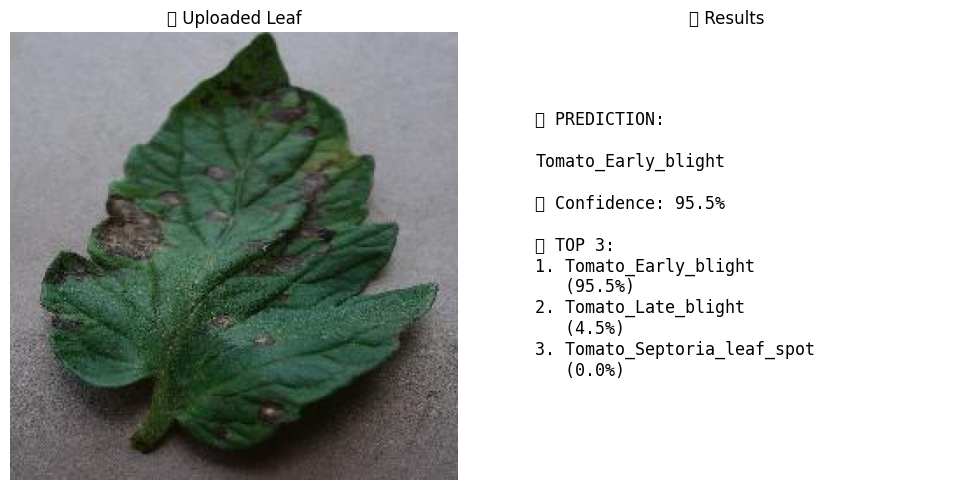


📊 RESULTS:
   ✅ Predicted: Tomato_Early_blight
   📈 Confidence: 95.48%

   🏆 Top 3 predictions:
      1. Tomato_Early_blight: 95.48%
      2. Tomato_Late_blight: 4.51%
      3. Tomato_Septoria_leaf_spot: 0.01%


In [22]:
from google.colab import files
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("="*50)
print("🌿 PLANT DISEASE PREDICTOR")
print("="*50)

# Upload image
print("\n📤 Step 1: Upload a plant leaf image")
uploaded = files.upload()

# Class names (from your training)
class_names = list(train_generator.class_indices.keys())

# Process each uploaded image
for filename in uploaded.keys():
    print(f"\n🔍 Processing: {filename}")

    # Step 2: Load and preprocess image
    img = tf.keras.utils.load_img(filename, target_size=(128, 128))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # Normalize

    # Step 3: Make prediction
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx] * 100

    # Get top 3 predictions
    top3_idx = np.argsort(predictions[0])[-3:][::-1]

    # Step 4: Display result
    plt.figure(figsize=(10, 5))

    # Show image
    plt.subplot(1, 2, 1)
    plt.imshow(tf.keras.utils.load_img(filename))
    plt.title(f"🌱 Uploaded Leaf", fontsize=12)
    plt.axis('off')

    # Show prediction text
    plt.subplot(1, 2, 2)
    plt.axis('off')
    result_text = f"✅ PREDICTION:\n\n{class_names[predicted_class_idx]}\n\n📊 Confidence: {confidence:.1f}%\n\n"
    result_text += f"🏆 TOP 3:\n"
    for i, idx in enumerate(top3_idx):
        result_text += f"{i+1}. {class_names[idx]}\n   ({predictions[0][idx]*100:.1f}%)\n"

    plt.text(0.1, 0.5, result_text, fontsize=12, verticalalignment='center', fontfamily='monospace')
    plt.title("📋 Results", fontsize=12)

    plt.tight_layout()
    plt.show()

    # Print to console
    print(f"\n📊 RESULTS:")
    print(f"   ✅ Predicted: {class_names[predicted_class_idx]}")
    print(f"   📈 Confidence: {confidence:.2f}%")
    print(f"\n   🏆 Top 3 predictions:")
    for i, idx in enumerate(top3_idx):
        print(f"      {i+1}. {class_names[idx]}: {predictions[0][idx]*100:.2f}%")

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

class_names = list(train_generator.class_indices.keys())
print(f"✅ Loaded {len(class_names)} classes")

last_conv_layer = None
for layer in model.layers:
    if 'conv2d' in layer.name and 'conv2d_2' in layer.name:
        last_conv_layer = layer.name
        break

if last_conv_layer is None:
    for layer in reversed(model.layers):
        if 'conv2d' in layer.name:
            last_conv_layer = layer.name
            break

print(f"✅ Using last conv layer: {last_conv_layer}")

dummy_input = tf.random.normal((1, 128, 128, 3))
_ = model(dummy_input)
print("✅ Model initialized")


def make_gradcam_heatmap(img_array):
    """Generate heatmap for your trained model"""

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_output)
    weights = tf.reduce_mean(grads, axis=(1, 2))
    heatmap = tf.reduce_sum(tf.multiply(weights, conv_output), axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-10)

    return heatmap.numpy()[0]


def display_gradcam(image_path):
    """Show original image, prediction, and heatmap"""

    original = tf.keras.utils.load_img(image_path)
    img = tf.keras.utils.load_img(image_path, target_size=(128, 128))
    img_array = tf.keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array / 255.0, axis=0)

    predictions = model.predict(img_batch, verbose=0)
    pred_idx = np.argmax(predictions[0])
    confidence = predictions[0][pred_idx] * 100
    pred_class = class_names[pred_idx]

    heatmap = make_gradcam_heatmap(img_batch)

    img_cv = cv2.cvtColor(np.array(original), cv2.COLOR_RGB2BGR)
    img_cv = cv2.resize(img_cv, (128, 128))

    heatmap_resized = cv2.resize(heatmap, (128, 128))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB), 0.6, heatmap_colored, 0.4, 0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(original)
    axes[0].set_title(f"Original\n{pred_class}\n{confidence:.1f}%")
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title("Grad-CAM Heatmap\n(Red = Important)")
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title("Overlay\n(Model focus area)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return pred_class, confidence

print("✅ Grad-CAM functions ready!")

✅ Loaded 15 classes
✅ Using last conv layer: conv2d_2
✅ Model initialized
✅ Grad-CAM functions ready!
